# 🔍 ELA + CNN v2 — Multi-Scale Architecture
**التحسين:** بدل kernel واحد، بنشوف الـ ELA بـ 3 مقاسات في نفس الوقت (1×1, 3×3, 5×5)
**السبب:** الـ confusion matrix وضحت إن الموديل بيغلط في الـ real أكتر — محتاج texture detail أدق

## 📦 Cell 1 — Setup

In [1]:
from google.colab import files
files.upload()  # ارفع kaggle.json
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip install -q tensorflow keras

Saving kaggle.json to kaggle.json


## 📥 Cell 2 — Download & Organize

In [2]:
!kaggle datasets download -d divg07/casia-20-image-tampering-detection-dataset
!unzip -q casia-20-image-tampering-detection-dataset.zip

import os, glob, shutil
import numpy as np
from PIL import Image, ImageChops, ImageEnhance
from sklearn.model_selection import train_test_split
from tqdm import tqdm

for cls in ['real', 'fake']:
    os.makedirs(f'CASIA_clf/{cls}', exist_ok=True)

for img in os.listdir('CASIA2/Au'):
    shutil.copy(f'CASIA2/Au/{img}', 'CASIA_clf/real')
for img in os.listdir('CASIA2/Tp'):
    shutil.copy(f'CASIA2/Tp/{img}', 'CASIA_clf/fake')

print(f"Real: {len(os.listdir('CASIA_clf/real'))} | Fake: {len(os.listdir('CASIA_clf/fake'))}")

Dataset URL: https://www.kaggle.com/datasets/divg07/casia-20-image-tampering-detection-dataset
License(s): unknown
100% 2.56G/2.56G [00:25<00:00, 109MB/s] 

Real: 7492 | Fake: 5125


## ✂️ Cell 3 — Train / Val / Test Split

In [3]:
for split in ['train', 'val', 'test']:
    for cls in ['real', 'fake']:
        os.makedirs(f'data/{split}/{cls}', exist_ok=True)

for cls in ['real', 'fake']:
    images = glob.glob(f'CASIA_clf/{cls}/*')
    train_imgs, temp    = train_test_split(images, test_size=0.30, random_state=42)
    val_imgs, test_imgs = train_test_split(temp,   test_size=0.50, random_state=42)
    for img in train_imgs: shutil.copy(img, f'data/train/{cls}')
    for img in val_imgs:   shutil.copy(img, f'data/val/{cls}')
    for img in test_imgs:  shutil.copy(img, f'data/test/{cls}')

for split in ['train', 'val', 'test']:
    r = len(os.listdir(f'data/{split}/real'))
    f = len(os.listdir(f'data/{split}/fake'))
    print(f'{split}: real={r} | fake={f} | total={r+f}')

train: real=5244 | fake=3587 | total=8831
val: real=1124 | fake=769 | total=1893
test: real=1124 | fake=769 | total=1893


## 🔬 Cell 4 — ELA Conversion

In [4]:
def convert_to_ela_image(path, quality=90):

    temp_filename = '/tmp/ela_tmp.jpg'
    image = Image.open(path).convert('RGB')
    image.save(temp_filename, 'JPEG', quality=quality)
    temp_image = Image.open(temp_filename)
    ela_image  = ImageChops.difference(image, temp_image)
    extrema    = ela_image.getextrema()
    max_diff   = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale     = 255.0 / max_diff
    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
    return ela_image

failed = 0
for split in ['train', 'val', 'test']:
    for cls in ['real', 'fake']:
        os.makedirs(f'data_ela/{split}/{cls}', exist_ok=True)
        for file in tqdm(os.listdir(f'data/{split}/{cls}'), desc=f'{split}/{cls}'):
            src = f'data/{split}/{cls}/{file}'
            dst = f'data_ela/{split}/{cls}/{os.path.splitext(file)[0]}.jpg'
            try:
                convert_to_ela_image(src).save(dst, 'JPEG', quality=95)
            except:
                failed += 1

print(f'\n✅ ELA done (v1 preprocessing) | failed: {failed}')
for split in ['train', 'val', 'test']:
    r = len(os.listdir(f'data_ela/{split}/real'))
    f = len(os.listdir(f'data_ela/{split}/fake'))
    print(f'  ELA {split}: real={r} | fake={f}')


test/fake: 100%|██████████| 769/769 [00:09<00:00, 84.96it/s]


✅ ELA done (v1 preprocessing) | failed: 3
  ELA train: real=5244 | fake=3585
  ELA val: real=1123 | fake=769
  ELA test: real=1124 | fake=769


## 👁️ Cell 5 — Visualize ELA

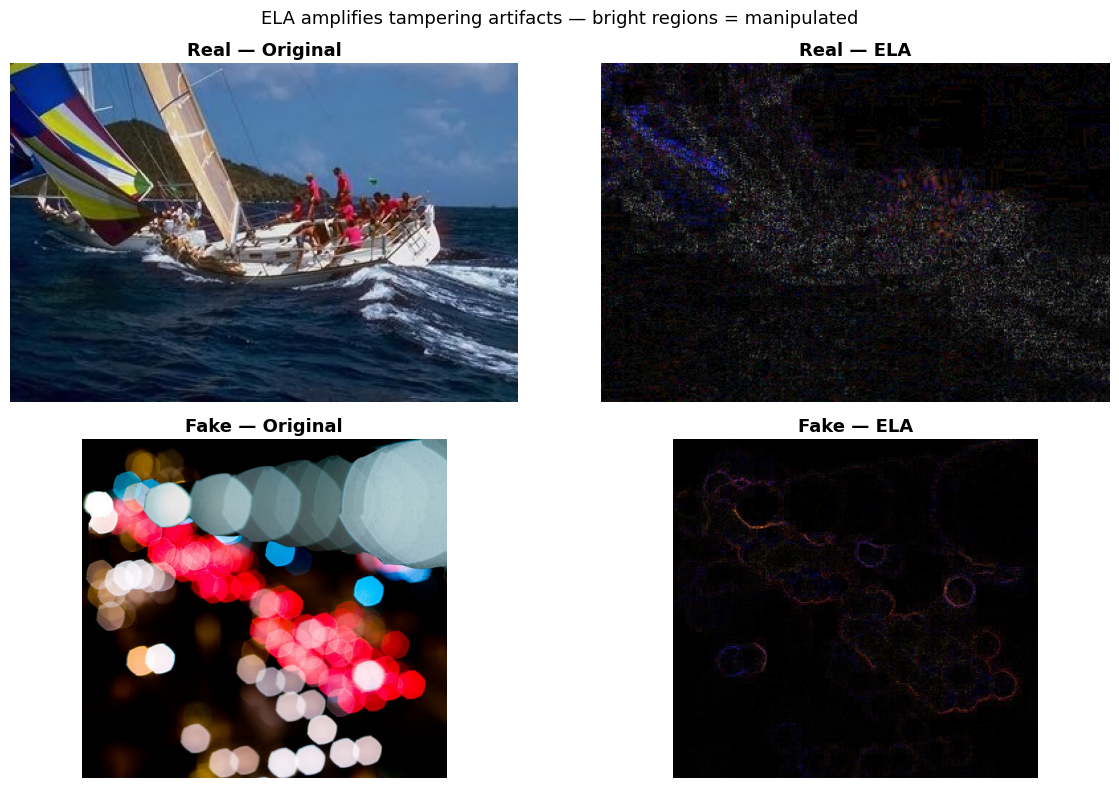

Real:  Au_sec_30515.jpg
Fake:  Tp_D_NRN_M_N_txt10111_txt10104_10810.jpg


In [5]:
import matplotlib.pyplot as plt
import random

real_files = glob.glob('data/test/real/*')
fake_files = glob.glob('data/test/fake/*')

real_orig = random.choice(real_files)
fake_orig = random.choice(fake_files)

real_ela = f"data_ela/test/real/{os.path.splitext(os.path.basename(real_orig))[0]}.jpg"
fake_ela = f"data_ela/test/fake/{os.path.splitext(os.path.basename(fake_orig))[0]}.jpg"

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for (r, c), (path, title) in zip(
    [(0,0),(0,1),(1,0),(1,1)],
    [(real_orig,'Real — Original'),(real_ela,'Real — ELA'),
     (fake_orig,'Fake — Original'),(fake_ela,'Fake — ELA')]
):
    axes[r][c].imshow(Image.open(path))
    axes[r][c].set_title(title, fontsize=13, fontweight='bold')
    axes[r][c].axis('off')

plt.suptitle('ELA amplifies tampering artifacts — bright regions = manipulated', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Real:  {os.path.basename(real_orig)}')
print(f'Fake:  {os.path.basename(fake_orig)}')


## 📚 Cell 6 — Imports & Config

In [6]:
import math
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout, Input,
    Multiply, Reshape, Activation, Concatenate, Add
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateScheduler
)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import keras.backend as K

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 60

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 🔄 Cell 7 — Data Generators

In [7]:
def make_generators(data_root, img_size=IMG_SIZE, batch=BATCH_SIZE):
    train_gen = ImageDataGenerator(
        rescale            = 1./255,
        horizontal_flip    = True,
        vertical_flip      = True,
        rotation_range     = 20,
        width_shift_range  = 0.1,
        height_shift_range = 0.1,
        zoom_range         = 0.15,
        shear_range        = 0.1,
        brightness_range   = [0.75, 1.25],
    ).flow_from_directory(
        f'{data_root}/train', target_size=img_size,
        batch_size=batch, class_mode='binary', shuffle=True
    )
    val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
        f'{data_root}/val', target_size=img_size,
        batch_size=batch, class_mode='binary', shuffle=False
    )
    test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
        f'{data_root}/test', target_size=img_size,
        batch_size=batch, class_mode='binary', shuffle=False
    )
    assert train_gen.class_indices == val_gen.class_indices == test_gen.class_indices, \
        f"Class mismatch! {train_gen.class_indices}"
    print(f'[{data_root}] classes={train_gen.class_indices}')
    print(f'  train={train_gen.samples} | val={val_gen.samples} | test={test_gen.samples}')
    return train_gen, val_gen, test_gen

## 🧠 Cell 8 — Build Multi-Scale CNN

### الفكرة الجديدة: **Inception-style Multi-Scale Block**

```
Input
  ├── Conv 1×1  →  fine details
  ├── Conv 3×3  →  medium patterns  
  └── Conv 5×5  →  coarse regions
        ↓
   Concatenate → SE Attention → Output
```

**ليه ده بيفيد ELA؟**  
الـ real images لها ELA pattern **uniform ومتجانس** على مستويات مختلفة  
الـ fake images لها **اختلاف واضح** بين الـ scales في مكان التلاعب  
الموديل يتعلم يكشف الاختلاف ده

In [8]:
def se_block(x, ratio=8):
    """Squeeze & Excitation — attention على الـ channels."""
    filters = x.shape[-1]
    se = GlobalAveragePooling2D()(x)
    se = Reshape((1, 1, filters))(se)
    se = Dense(max(filters // ratio, 8), activation='relu',   use_bias=False)(se)
    se = Dense(filters,                  activation='sigmoid', use_bias=False)(se)
    return Multiply()([x, se])


def inception_block(x, f1, f3, f5):
    """
    Multi-Scale block: بيشوف الـ ELA بـ 3 مقاسات في نفس الوقت.
    f1, f3, f5 = عدد الـ filters لكل branch
    """
    # Branch 1: 1×1 — بيلتقط الـ pixel-level ELA differences
    b1 = Conv2D(f1, 1, padding='same', use_bias=False)(x)
    b1 = BatchNormalization()(b1)
    b1 = Activation('relu')(b1)

    # Branch 2: 3×3 — الـ local texture patterns
    b2 = Conv2D(f3, 1, padding='same', use_bias=False)(x)  # bottleneck أولاً
    b2 = BatchNormalization()(b2)
    b2 = Activation('relu')(b2)
    b2 = Conv2D(f3, 3, padding='same', use_bias=False)(b2)
    b2 = BatchNormalization()(b2)
    b2 = Activation('relu')(b2)

    # Branch 3: 5×5 — الـ regional compression artifacts
    b3 = Conv2D(f5, 1, padding='same', use_bias=False)(x)  # bottleneck
    b3 = BatchNormalization()(b3)
    b3 = Activation('relu')(b3)
    b3 = Conv2D(f5, 5, padding='same', use_bias=False)(b3)
    b3 = BatchNormalization()(b3)
    b3 = Activation('relu')(b3)

    # Merge الـ 3 branches
    out = Concatenate()([b1, b2, b3])
    out = se_block(out)   # attention بعد الـ merge
    return out


def build_multiscale_cnn(input_shape=(128, 128, 3)):
    inp = Input(shape=input_shape)

    # ── Stem: نستخرج features أولية ─────────────────────────────────────────
    x = Conv2D(32, 3, padding='same', use_bias=False)(inp)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)          # 128 → 64
    x = Dropout(0.1)(x)

    # ── Block 1: Multi-Scale (64→32) ─────────────────────────────────────────
    x = inception_block(x, f1=32, f3=64, f5=32)   # out: 128 channels
    x = MaxPooling2D(2)(x)          # 64 → 32
    x = Dropout(0.2)(x)

    # ── Block 2: Multi-Scale (32→16) ─────────────────────────────────────────
    x = inception_block(x, f1=64, f3=128, f5=64)  # out: 256 channels
    x = MaxPooling2D(2)(x)          # 32 → 16
    x = Dropout(0.25)(x)

    # ── Block 3: Multi-Scale (16→8) ──────────────────────────────────────────
    x = inception_block(x, f1=96, f3=192, f5=96)  # out: 384 channels
    x = MaxPooling2D(2)(x)          # 16 → 8
    x = Dropout(0.3)(x)

    # ── Head ─────────────────────────────────────────────────────────────────
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(64,  activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(1, activation='sigmoid')(x)

    return Model(inp, out)


# ── Preview ───────────────────────────────────────────────────────────────────
m = build_multiscale_cnn()
m.summary()
print(f'\nTotal params: {m.count_params():,}')
del m

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      2,048 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │      1,024 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      1,024 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     36,864 │ activation_3[0][

 Total params: 1,197,793 (4.57 MB)

 Trainable params: 1,194,977 (4.56 MB)

 Non-trainable params: 2,816 (11.00 KB)


Total params: 1,197,793


## ⚙️ Cell 9 — LR Schedule & Compile

In [9]:
def warmup_cosine(epoch, lr,
                  warmup=5, total=EPOCHS,
                  lr_max=8e-4, lr_min=1e-6):
    """5 epochs warm-up ثم Cosine Decay."""
    if epoch < warmup:
        return lr_min + (lr_max - lr_min) * (epoch / warmup)
    progress = (epoch - warmup) / (total - warmup)
    return lr_min + (lr_max - lr_min) * 0.5 * (1 + math.cos(math.pi * progress))


def compile_model(model):
    model.compile(
        optimizer = AdamW(learning_rate=8e-4, weight_decay=1e-4),
        loss      = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics   = ['accuracy']
    )
    return model


def get_callbacks(save_path):
    return [
        ModelCheckpoint(
            save_path, monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        EarlyStopping(
            monitor='val_accuracy', patience=15,
            restore_best_weights=True, verbose=1
        ),
        LearningRateScheduler(warmup_cosine, verbose=0),
    ]

print('✅ LR Schedule: warm-up 5 epochs → cosine decay to 1e-6')

✅ LR Schedule: warm-up 5 epochs → cosine decay to 1e-6


## 🟧 Cell 10 — Train on ELA Data

In [10]:
K.clear_session()

train_ela, val_ela, test_ela = make_generators('data_ela')

# Class weights عشان نعالج الـ imbalance
n_fake  = train_ela.classes.tolist().count(0)
n_real  = train_ela.classes.tolist().count(1)
n_total = n_fake + n_real
class_weight_ela = {
    0: n_total / (2 * n_fake),   # fake
    1: n_total / (2 * n_real),   # real
}
print(f'Class weights: {class_weight_ela}')

model_ela = compile_model(build_multiscale_cnn())

print('\n🔥 Training on ELA Data...')
history_ela = model_ela.fit(
    train_ela,
    validation_data = val_ela,
    epochs          = EPOCHS,
    class_weight    = class_weight_ela,
    callbacks       = get_callbacks('best_ela_v2.keras'),
    verbose         = 1
)

Found 8829 images belonging to 2 classes.
Found 1892 images belonging to 2 classes.
Found 1893 images belonging to 2 classes.
[data_ela] classes={'fake': 0, 'real': 1}
  train=8829 | val=1892 | test=1893
Class weights: {0: 1.2313807531380754, 1: 0.8418192219679634}

🔥 Training on ELA Data...
Epoch 1/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.6156 - loss: 0.6585
Epoch 1: val_accuracy improved from None to 0.40645, saving model to best_ela_v2.keras

Epoch 1: finished saving model to best_ela_v2.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 140s 385ms/step - accuracy: 0.6433 - loss: 0.6384 - val_accuracy: 0.4064 - val_loss: 0.7100 - learning_rate: 1.0000e-06
Epoch 2/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.8097 - loss: 0.4650
Epoch 2: val_accuracy improved from 0.40645 to 0.40698, saving model to best_ela_v2.keras

Epoch 2: finished saving model to best_ela_v2.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 72s 262ms/step - accuracy: 0.8328 - loss: 0.4382 - val_accuracy: 0.407

## ✅ Cell 11 — Evaluate ELA Model

Found 8829 images belonging to 2 classes.
Found 1892 images belonging to 2 classes.
Found 1893 images belonging to 2 classes.
[data_ela] classes={'fake': 0, 'real': 1}
  train=8829 | val=1892 | test=1893
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step

🏆 ELA Test Accuracy: 92.08%

📋 Classification Report:
              precision    recall  f1-score   support

        fake       0.88      0.94      0.91       769
        real       0.96      0.91      0.93      1124

    accuracy                           0.92      1893
   macro avg       0.92      0.92      0.92      1893
weighted avg       0.92      0.92      0.92      1893



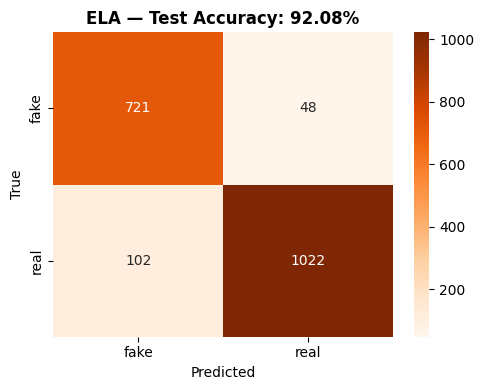

In [11]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

best_ela = load_model('best_ela_v2.keras')

_, _, test_ela_fresh = make_generators('data_ela')

_, ela_acc = best_ela.evaluate(test_ela_fresh, verbose=0)
ela_acc *= 100

test_ela_fresh.reset()
y_pred_ela = (best_ela.predict(test_ela_fresh) > 0.5).astype(int).flatten()
y_true_ela = test_ela_fresh.classes

print(f'\n🏆 ELA Test Accuracy: {ela_acc:.2f}%')
print('\n📋 Classification Report:')
print(classification_report(y_true_ela, y_pred_ela, target_names=['fake','real']))

cm_ela = confusion_matrix(y_true_ela, y_pred_ela)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ela, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['fake','real'], yticklabels=['fake','real'])
plt.title(f'ELA — Test Accuracy: {ela_acc:.2f}%', fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

## 🟦 Cell 12 — Train on Original Data

In [12]:
K.clear_session()

train_orig, val_orig, test_orig = make_generators('data')

n_fake  = train_orig.classes.tolist().count(0)
n_real  = train_orig.classes.tolist().count(1)
n_total = n_fake + n_real
class_weight_orig = {
    0: n_total / (2 * n_fake),
    1: n_total / (2 * n_real),
}
print(f'Class weights: {class_weight_orig}')

model_orig = compile_model(build_multiscale_cnn())

print('\n🔥 Training on Original Data...')
history_orig = model_orig.fit(
    train_orig,
    validation_data = val_orig,
    epochs          = EPOCHS,
    class_weight    = class_weight_orig,
    callbacks       = get_callbacks('best_orig_v2.keras'),
    verbose         = 1
)

Found 8829 images belonging to 2 classes.
Found 1892 images belonging to 2 classes.
Found 1893 images belonging to 2 classes.
[data] classes={'fake': 0, 'real': 1}
  train=8829 | val=1892 | test=1893
Class weights: {0: 1.2313807531380754, 1: 0.8418192219679634}

🔥 Training on Original Data...
Epoch 1/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.5737 - loss: 0.7532
Epoch 1: val_accuracy improved from None to 0.59355, saving model to best_orig_v2.keras

Epoch 1: finished saving model to best_orig_v2.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 129s 372ms/step - accuracy: 0.5548 - loss: 0.7543 - val_accuracy: 0.5936 - val_loss: 0.6860 - learning_rate: 1.0000e-06
Epoch 2/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.5481 - loss: 0.6985
Epoch 2: val_accuracy improved from 0.59355 to 0.62474, saving model to best_orig_v2.keras

Epoch 2: finished saving model to best_orig_v2.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 72s 260ms/step - accuracy: 0.5681 - loss: 0.6854 - val_accuracy: 

## ✅ Cell 13 — Evaluate Original Model

Found 8829 images belonging to 2 classes.
Found 1892 images belonging to 2 classes.
Found 1893 images belonging to 2 classes.
[data] classes={'fake': 0, 'real': 1}
  train=8829 | val=1892 | test=1893
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step

🏆 Original Test Accuracy: 88.06%

📋 Classification Report:
              precision    recall  f1-score   support

        fake       0.79      0.95      0.87       769
        real       0.96      0.83      0.89      1124

    accuracy                           0.88      1893
   macro avg       0.88      0.89      0.88      1893
weighted avg       0.89      0.88      0.88      1893



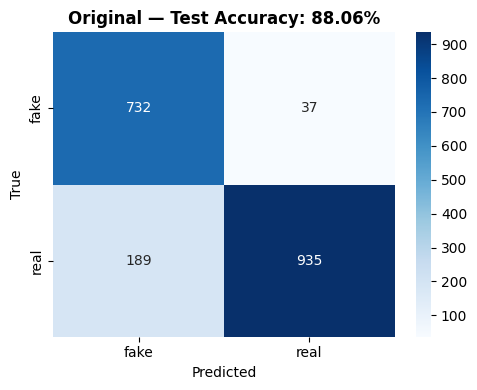

In [13]:
best_orig = load_model('best_orig_v2.keras')

_, _, test_orig_fresh = make_generators('data')

_, orig_acc = best_orig.evaluate(test_orig_fresh, verbose=0)
orig_acc *= 100

test_orig_fresh.reset()
y_pred_orig = (best_orig.predict(test_orig_fresh) > 0.5).astype(int).flatten()
y_true_orig = test_orig_fresh.classes

print(f'\n🏆 Original Test Accuracy: {orig_acc:.2f}%')
print('\n📋 Classification Report:')
print(classification_report(y_true_orig, y_pred_orig, target_names=['fake','real']))

cm_orig = confusion_matrix(y_true_orig, y_pred_orig)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues',
            xticklabels=['fake','real'], yticklabels=['fake','real'])
plt.title(f'Original — Test Accuracy: {orig_acc:.2f}%', fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

## 📊 Cell 14 — Final Comparison

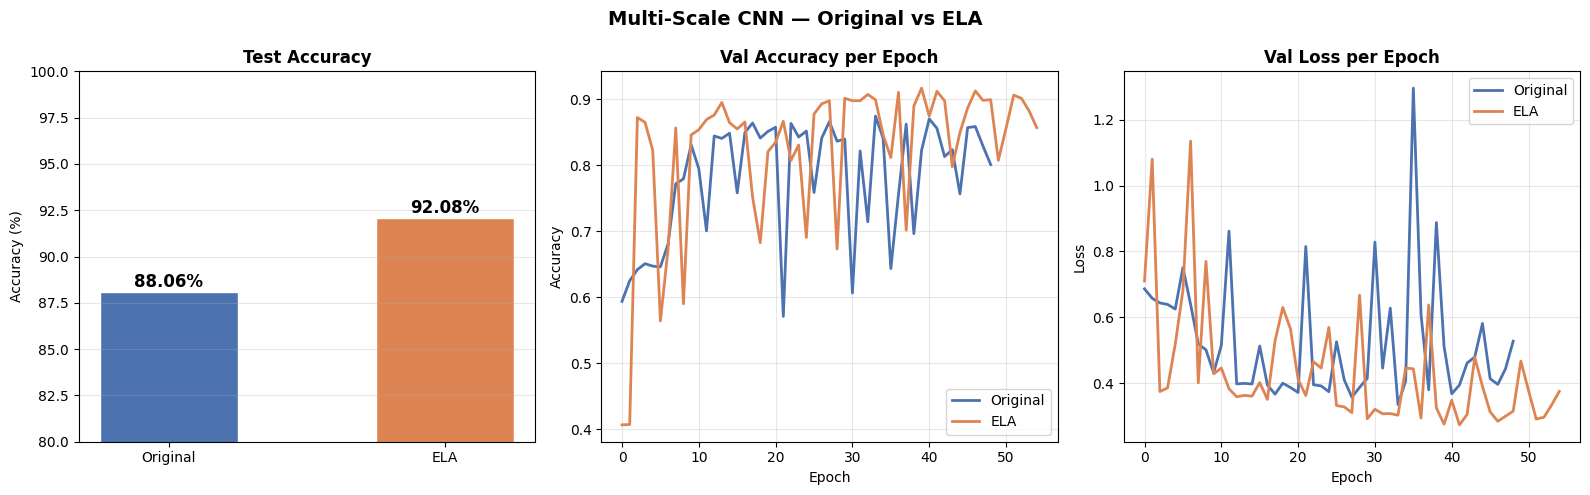


  FINAL RESULTS — Multi-Scale CNN v2
  Original Data  →  88.06%
  ELA Data       →  92.08%
  ELA Gain       →  +4.01%


In [14]:
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Bar: Accuracy ────────────────────────────────────────────────────────────
colors = ['#4C72B0', '#DD8452']
bars = axes[0].bar(['Original', 'ELA'], [orig_acc, ela_acc],
                    color=colors, width=0.5, edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.2f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(80, 100)
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].grid(axis='y', alpha=0.3)

# ── Val Accuracy curves ───────────────────────────────────────────────────────
axes[1].plot(history_orig.history['val_accuracy'], label='Original', color=colors[0], lw=2)
axes[1].plot(history_ela.history['val_accuracy'],  label='ELA',      color=colors[1], lw=2)
axes[1].set_title('Val Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ── Val Loss curves ───────────────────────────────────────────────────────────
axes[2].plot(history_orig.history['val_loss'], label='Original', color=colors[0], lw=2)
axes[2].plot(history_ela.history['val_loss'],  label='ELA',      color=colors[1], lw=2)
axes[2].set_title('Val Loss per Epoch', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Multi-Scale CNN — Original vs ELA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Table ─────────────────────────────────────────────────────────────
print('\n' + '='*45)
print('  FINAL RESULTS — Multi-Scale CNN v2')
print('='*45)
print(f'  Original Data  →  {orig_acc:.2f}%')
print(f'  ELA Data       →  {ela_acc:.2f}%')
print(f'  ELA Gain       →  {ela_acc - orig_acc:+.2f}%')
print('='*45)
